In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Кластеризация пользователей Steam (простая K-Means)

### Загрузка и фильтраци данных

In [ ]:
with open('../data/steamUsersDataset.json', encoding='utf-8') as file:
    steamUsersDataset = json.load(file)

filteredSteamUsersDataset = []
for user in steamUsersDataset:
    errorFlag = user.get('error')
    if not errorFlag:
        filteredSteamUsersDataset.append(user)

print(f"Публичных пользователей для кластеризации: {len(filteredSteamUsersDataset)}")

Публичных пользователей для кластеризации: 4082


### Feature Engineering - создаём простые числовые признаки для каждого пользователя

In [ ]:
userFeaturesList = []

for user in filteredSteamUsersDataset:
    steamId = user.get('steamId')
    numberOfOwnedGames = len(user.get('ownedGames', []))
    
    totalPlaytimeMinutes = 0
    for game in user.get('ownedGames', []):
        totalPlaytimeMinutes += game.get('playtimeForever', 0)
    
    totalPlaytimeHours = totalPlaytimeMinutes / 60.0
    averagePlaytimeHours = totalPlaytimeHours / numberOfOwnedGames if numberOfOwnedGames > 0 else 0
    
    # Дополнительный признак: доля "долгих" игр (playtime > 50 часов)
    longGamesCount = sum(1 for game in user.get('ownedGames', []) if game.get('playtimeForever', 0) > 3000)  # >50 часов
    longGamesRatio = longGamesCount / numberOfOwnedGames if numberOfOwnedGames > 0 else 0
    
    userFeaturesList.append({
        'steamId': steamId,
        'numberOfOwnedGames': numberOfOwnedGames,
        'totalPlaytimeHours': totalPlaytimeHours,
        'averagePlaytimeHours': averagePlaytimeHours,
        'longGamesRatio': longGamesRatio
    })

userFeaturesDataFrame = pd.DataFrame(userFeaturesList)
print("Признаки для кластеризации:")
print(userFeaturesDataFrame.describe())

Признаки для кластеризации:
       numberOfOwnedGames  totalPlaytimeHours  averagePlaytimeHours  \
count         4082.000000         4082.000000           4082.000000   
mean            75.788339         3915.512976            118.286005   
std            138.075399         4727.346852            242.594214   
min              1.000000            0.000000              0.000000   
25%             14.000000          830.387500             28.812905   
50%             37.000000         2525.833333             60.802540   
75%             87.000000         5410.429167            122.766667   
max           3375.000000        78910.866667           7294.500000   

       longGamesRatio  
count     4082.000000  
mean         0.152583  
std          0.164307  
min          0.000000  
25%          0.062500  
50%          0.113704  
75%          0.185185  
max          1.000000  


### Масштабирование признаков (обязательно для K-Means)

In [ ]:
featuresForClustering = ['numberOfOwnedGames', 'totalPlaytimeHours', 'averagePlaytimeHours', 'longGamesRatio']
X = userFeaturesDataFrame[featuresForClustering].values

scaler = StandardScaler()
XScaled = scaler.fit_transform(X)

print("Данные масштабированы. Размер матрицы:", XScaled.shape)

Данные масштабированы. Размер матрицы: (4082, 4)


### Elbow method - выбор оптимального числа кластеров

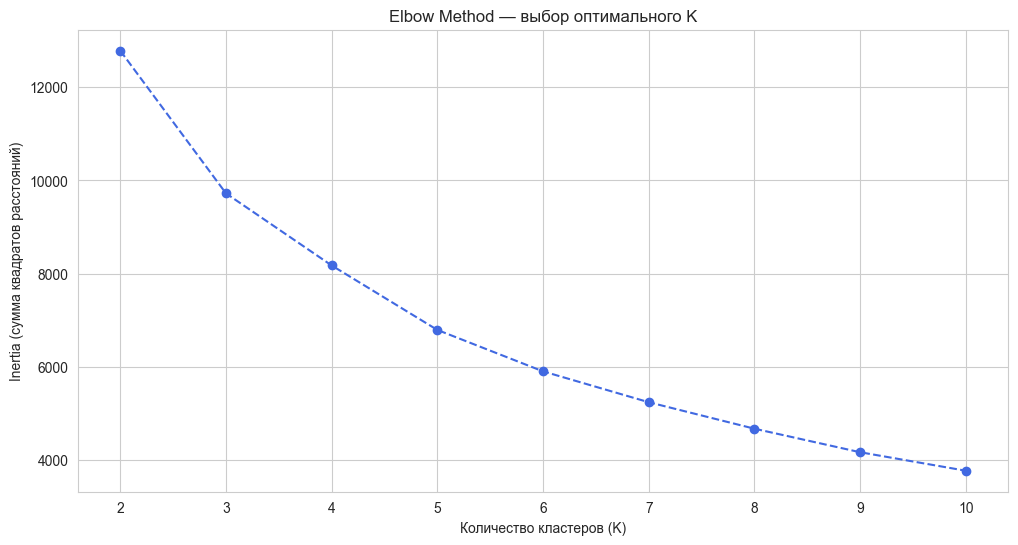

In [ ]:
inertiaList = []
kRange = range(2, 11)

for k in kRange:
    kmeansTemp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeansTemp.fit(XScaled)
    inertiaList.append(kmeansTemp.inertia_)

plt.figure()
plt.plot(kRange, inertiaList, marker='o', linestyle='--', color='royalblue')
plt.title('Elbow Method — выбор оптимального K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Inertia (сумма квадратов расстояний)')
plt.grid(True)
plt.show()

### Запуск K-Means кластеризации

In [ ]:
optimalK = 4
kmeans = KMeans(n_clusters=optimalK, random_state=42, n_init=10)
userFeaturesDataFrame['cluster'] = kmeans.fit_predict(XScaled)

print(f"Выполнена кластеризация на {optimalK} кластеров")
print(userFeaturesDataFrame['cluster'].value_counts())

Выполнена кластеризация на 4 кластеров
cluster
1    3047
3     769
0     220
2      46
Name: count, dtype: int64


### Визуализация кластеров в 2D с помощью PCA

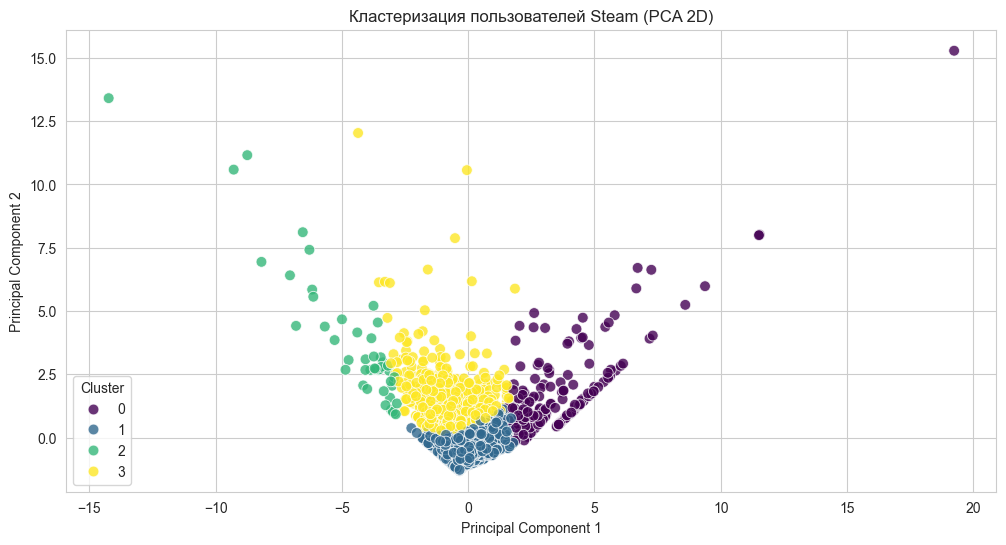

In [ ]:
pca = PCA(n_components=2, random_state=42)
principalComponents = pca.fit_transform(XScaled)
userFeaturesDataFrame['pca1'] = principalComponents[:, 0]
userFeaturesDataFrame['pca2'] = principalComponents[:, 1]

plt.figure()
sns.scatterplot(
    data=userFeaturesDataFrame,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='viridis',
    s=60,
    alpha=0.8
)
plt.title('Кластеризация пользователей Steam (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### 3D визуализация кластеров с помощью PCA 

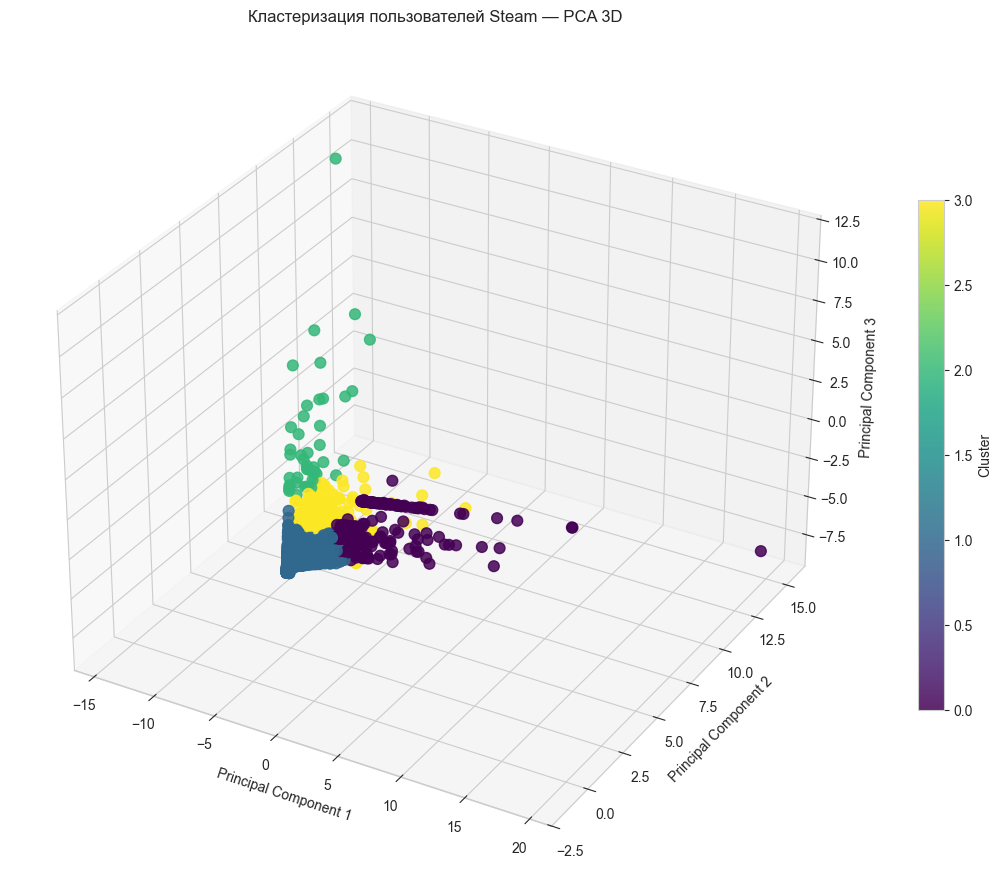

In [ ]:
pca3d = PCA(n_components=3, random_state=42)
principalComponents3d = pca3d.fit_transform(XScaled)

userFeaturesDataFrame['pca1_3d'] = principalComponents3d[:, 0]
userFeaturesDataFrame['pca2_3d'] = principalComponents3d[:, 1]
userFeaturesDataFrame['pca3_3d'] = principalComponents3d[:, 2]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    userFeaturesDataFrame['pca1_3d'],
    userFeaturesDataFrame['pca2_3d'],
    userFeaturesDataFrame['pca3_3d'],
    c=userFeaturesDataFrame['cluster'],
    cmap='viridis',
    s=60,
    alpha=0.85
)

ax.set_title('Кластеризация пользователей Steam - PCA 3D')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.colorbar(scatter, ax=ax, label='Cluster', shrink=0.6)

plt.tight_layout()
plt.show()

### Box-plot признаков по кластерам

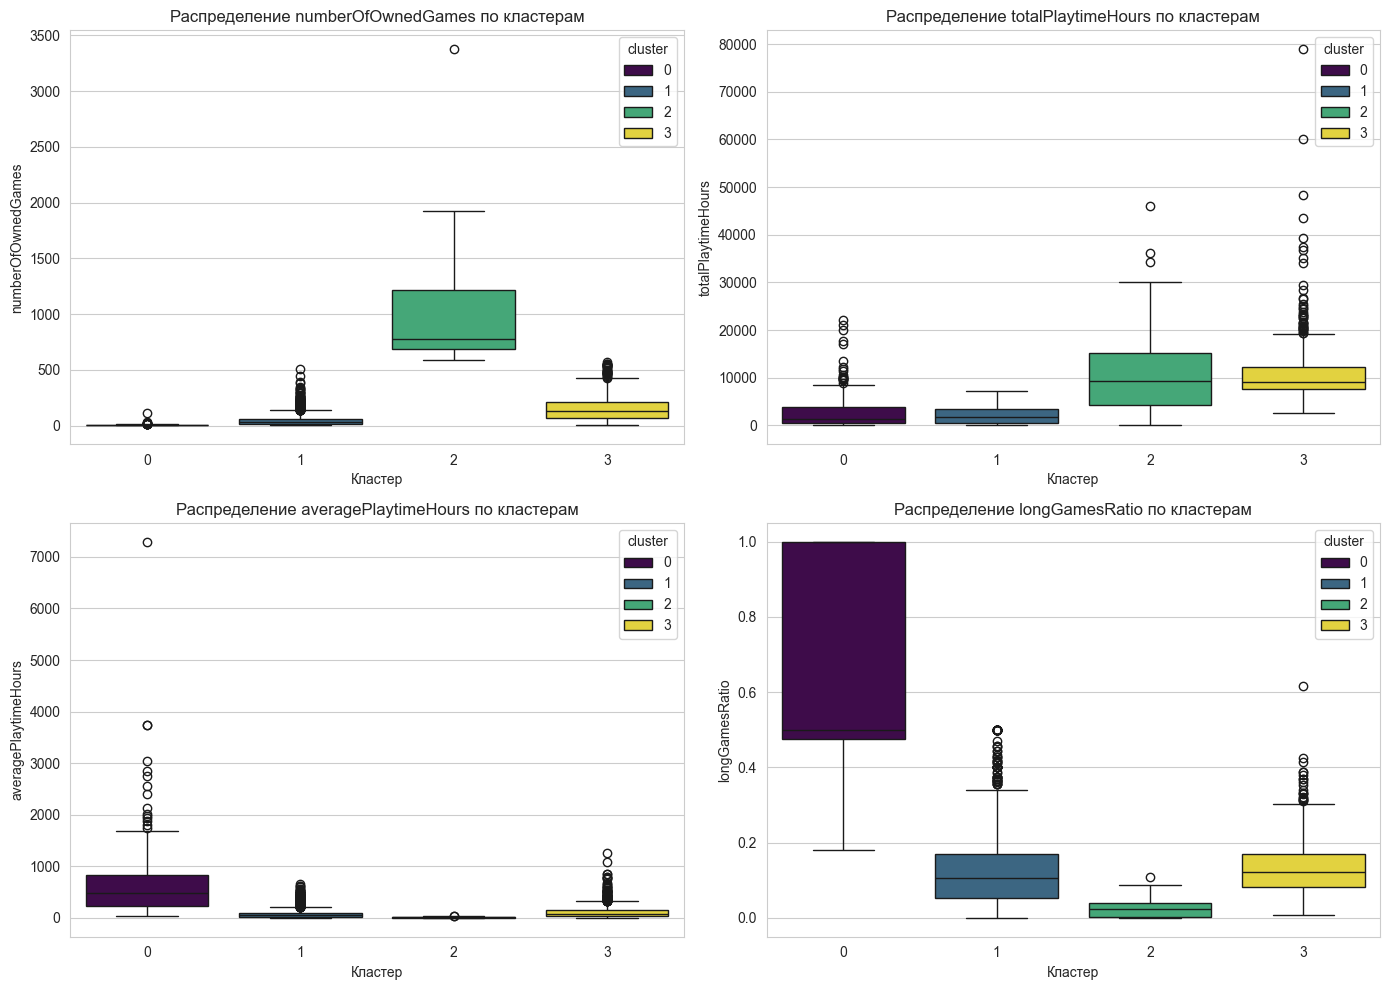

In [ ]:
featuresToPlot = ['numberOfOwnedGames', 'totalPlaytimeHours', 'averagePlaytimeHours', 'longGamesRatio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(featuresToPlot):
    sns.boxplot(data=userFeaturesDataFrame, x='cluster', y=feature, hue='cluster', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Распределение {feature} по кластерам')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

In [ ]:
clusterDescription = userFeaturesDataFrame.groupby('cluster')[featuresForClustering].mean().round(2)
print("Средние значения признаков по кластерам:")
print(clusterDescription)

Средние значения признаков по кластерам:
         numberOfOwnedGames  totalPlaytimeHours  averagePlaytimeHours  \
cluster                                                                 
0                      4.55             2909.69                678.27   
1                     46.36             2159.10                 76.64   
2                   1000.17            11512.67                 12.07   
3                    157.46            10708.23                129.44   

         longGamesRatio  
cluster                  
0                  0.66  
1                  0.12  
2                  0.03  
3                  0.13  


### Сохранение классов

In [ ]:
userFeaturesDataFrame.to_csv('../data/userClusters.csv', index=False)
print("Результаты кластеризации сохранены в data/userClusters.csv")

Результаты кластеризации сохранены в data/userClusters.csv
